In [1]:
import pandas as pd

# Carregando os dados da nova pasta organizada
dados = pd.read_csv('dados/emp_automovel.csv')
dados


,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [2]:
x = dados.drop('inadimplente', axis=1)
y = dados['inadimplente']

In [3]:
from sklearn.tree import DecisionTreeClassifier

In [4]:
modelo = DecisionTreeClassifier()
modelo.fit(x, y)
modelo.score(x, y)

1.0

In [5]:
print(f'Acurácia: {modelo.score(x, y)}')

Acurácia: 1.0


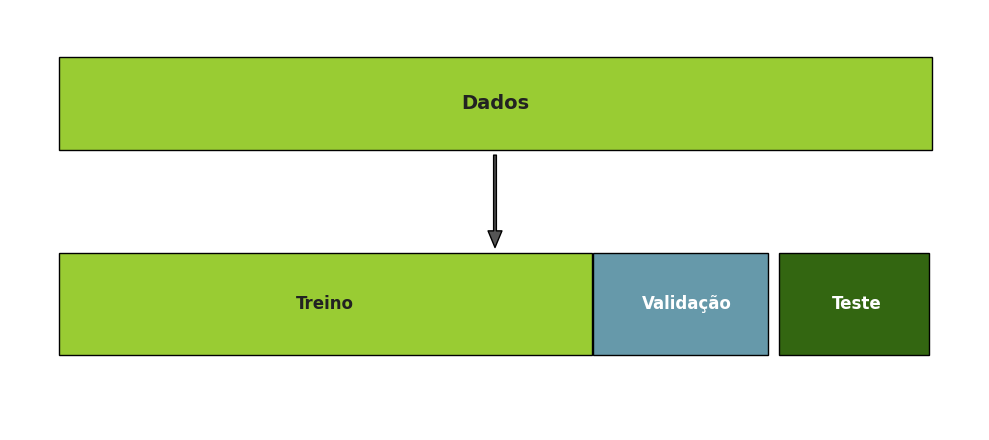

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura
fig, ax = plt.subplots(figsize=(10, 4.5))

# Estilo dos blocos (Cores)
cor_dados = '#99cc33'       
cor_treino = '#99cc33'      
cor_validacao = '#6699aa'   
cor_teste = '#336611'       

# 1. Bloco de "Dados" (Topo)
ax.add_patch(patches.Rectangle((0.5, 3.0), 9.0, 1.0, edgecolor='black', facecolor=cor_dados, lw=1))
ax.text(5.0, 3.5, 'Dados', fontsize=14, fontweight='bold', ha='center', va='center', color='#222222')

# Seta indicativa para baixo
ax.annotate('', xy=(5.0, 1.9), xytext=(5.0, 3.0),
            arrowprops=dict(facecolor='#555555', shrink=0.05, width=2, headwidth=10))

# 2. Blocos de Divisão (Base) - Com espaçamento reduzido
# Treino (Largura: 5.5)
ax.add_patch(patches.Rectangle((0.5, 0.8), 5.5, 1.1, edgecolor='black', facecolor=cor_treino, lw=1))
ax.text(3.25, 1.35, 'Treino', fontsize=12, fontweight='bold', ha='center', va='center', color='#222222')

# Validação (Começa logo após o Treino, apenas 0.08 de espaço)
ax.add_patch(patches.Rectangle((6.01, 0.8), 1.8, 1.1, edgecolor='black', facecolor=cor_validacao, lw=1))
ax.text(6.98, 1.35, 'Validação', fontsize=12, fontweight='bold', ha='center', va='center', color='white')

# Teste (Começa logo após a Validação, apenas 0.08 de espaço)
ax.add_patch(patches.Rectangle((7.93, 0.8), 1.54, 1.1, edgecolor='black', facecolor=cor_teste, lw=1))
ax.text(8.73, 1.35, 'Teste', fontsize=12, fontweight='bold', ha='center', va='center', color='white')

# Ajustes finais dos eixos
ax.set_xlim(0, 10)
ax.set_ylim(0, 4.5)
ax.axis('off')

plt.tight_layout()
plt.show()


In [7]:
from sklearn.model_selection import train_test_split


In [8]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify=y, random_state=5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify=y, random_state=5)

In [9]:
modelo = DecisionTreeClassifier()
modelo.fit(x_treino, y_treino)
print(f'Acurácia de Treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de Validação: {modelo.score(x_val, y_val)}')

Acurácia de Treino: 1.0
Acurácia de Validação: 0.8487065586621374


In [10]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_treino, y_treino)
print(f'Acurácia de Treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de Validação: {modelo.score(x_val, y_val)}')

Acurácia de Treino: 0.9205865272938444
Acurácia de Validação: 0.9056702377841651


In [11]:
from sklearn.metrics import confusion_matrix


In [12]:
y_previsto = modelo.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(matriz_confusao)

[[10356   123]
 [  960    42]]


In [13]:
from sklearn.metrics import ConfusionMatrixDisplay


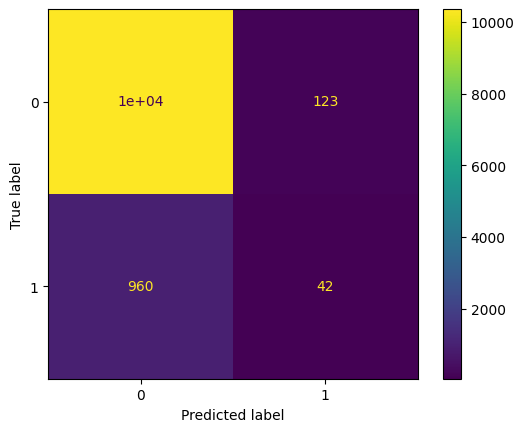

In [14]:
vizualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao)
vizualizacao.plot()

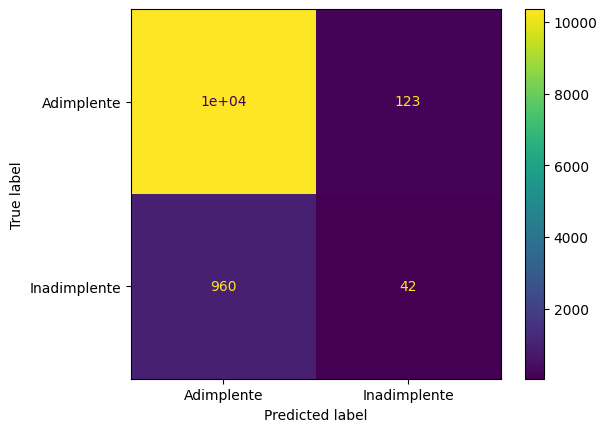

In [15]:
vizualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
vizualizacao.plot()

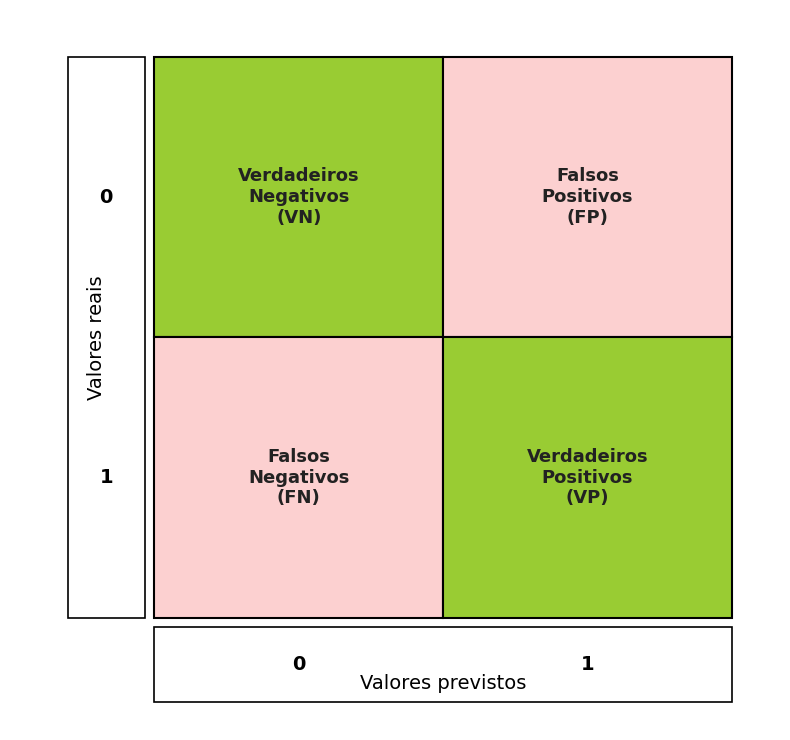

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura
fig, ax = plt.subplots(figsize=(8, 7.5))

# Cores fiéis à imagem do curso
cor_acerto = '#99cc33'     # Verde claro (Verdadeiros)
cor_erro = '#fcd0d0'       # Rosa claro (Falsos)

# 1. Desenhar os Quadrantes Principais da Matriz
# Verdadeiros Negativos (VN)
ax.add_patch(patches.Rectangle((2, 4), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(3.5, 5.5, 'Verdadeiros\nNegativos\n(VN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Positivos (FP)
ax.add_patch(patches.Rectangle((5, 4), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(6.5, 5.5, 'Falsos\nPositivos\n(FP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Negativos (FN)
ax.add_patch(patches.Rectangle((2, 1), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(3.5, 2.5, 'Falsos\nNegativos\n(FN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Verdadeiros Positivos (VP)
ax.add_patch(patches.Rectangle((5, 1), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(6.5, 2.5, 'Verdadeiros\nPositivos\n(VP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# 2. Caixa Lateral Esquerda ("Valores reais") - Fechando o retângulo completo
ax.add_patch(patches.Rectangle((1.1, 1.0), 0.8, 6.0, edgecolor='black', facecolor='none', lw=1.2))
ax.text(1.5, 5.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.5, 2.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.4, 4.0, 'Valores reais', fontsize=14, rotation=90, ha='center', va='center')

# 3. Caixa Inferior ("Valores previstos") - Fechando o retângulo completo
ax.add_patch(patches.Rectangle((2.0, 0.1), 6.0, 0.8, edgecolor='black', facecolor='none', lw=1.2))
ax.text(3.5, 0.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(6.5, 0.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(5.0, 0.3, 'Valores previstos', fontsize=14, ha='center', va='center')

# Ajustes de exibição para esconder os eixos do gráfico padrão
ax.set_xlim(0.5, 8.5)
ax.set_ylim(-0.2, 7.5)
ax.axis('off')

plt.tight_layout()
plt.show()


In [17]:
from sklearn.metrics import accuracy_score 

In [18]:
print(f'Acurácia: {accuracy_score(y_val, y_previsto)}')

Acurácia: 0.9056702377841651


In [19]:
from sklearn.metrics import precision_score, recall_score

In [20]:
print(f'Precisão: {precision_score(y_val, y_previsto)}')
print(f'Recall: {recall_score(y_val, y_previsto)}')

Precisão: 0.2545454545454545
Recall: 0.041916167664670656


In [21]:
from sklearn.metrics import f1_score

In [22]:
print(f'F1-Score: {f1_score(y_val, y_previsto)}')

F1-Score: 0.07197943444730077


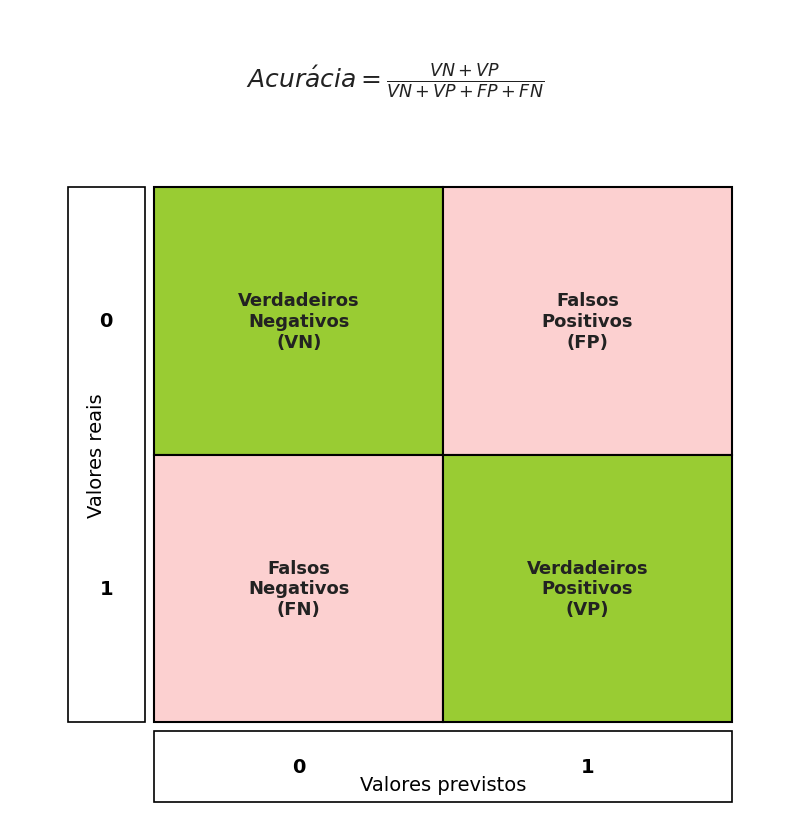

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura (aumentada na altura para caber a fórmula)
fig, ax = plt.subplots(figsize=(8, 8.5))

# Fórmula Matemática no Topo (usando sintaxe LaTeX nativa do Matplotlib)
ax.text(4.5, 8.2, r'$Acur\acute{a}cia = \frac{VN + VP}{VN + VP + FP + FN}$', 
        fontsize=18, fontweight='bold', ha='center', va='center', color='#222222')

# Cores fiéis à imagem do curso
cor_acerto = '#99cc33'     # Verde claro (Verdadeiros)
cor_erro = '#fcd0d0'       # Rosa claro (Falsos)

# 1. Desenhar os Quadrantes Principais da Matriz
# Verdadeiros Negativos (VN)
ax.add_patch(patches.Rectangle((2, 4), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(3.5, 5.5, 'Verdadeiros\nNegativos\n(VN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Positivos (FP)
ax.add_patch(patches.Rectangle((5, 4), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(6.5, 5.5, 'Falsos\nPositivos\n(FP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Falsos Negativos (FN)
ax.add_patch(patches.Rectangle((2, 1), 3, 3, edgecolor='black', facecolor=cor_erro, lw=1.5))
ax.text(3.5, 2.5, 'Falsos\nNegativos\n(FN)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# Verdadeiros Positivos (VP)
ax.add_patch(patches.Rectangle((5, 1), 3, 3, edgecolor='black', facecolor=cor_acerto, lw=1.5))
ax.text(6.5, 2.5, 'Verdadeiros\nPositivos\n(VP)', fontsize=13, fontweight='bold', ha='center', va='center', color='#222222')

# 2. Caixa Lateral Esquerda ("Valores reais")
ax.add_patch(patches.Rectangle((1.1, 1.0), 0.8, 6.0, edgecolor='black', facecolor='none', lw=1.2))
ax.text(1.5, 5.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.5, 2.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(1.4, 4.0, 'Valores reais', fontsize=14, rotation=90, ha='center', va='center')

# 3. Caixa Inferior ("Valores previstos")
ax.add_patch(patches.Rectangle((2.0, 0.1), 6.0, 0.8, edgecolor='black', facecolor='none', lw=1.2))
ax.text(3.5, 0.5, '0', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(6.5, 0.5, '1', fontsize=14, fontweight='bold', ha='center', va='center')
ax.text(5.0, 0.3, 'Valores previstos', fontsize=14, ha='center', va='center')

# Ajustes de exibição para esconder os eixos do gráfico padrão
ax.set_xlim(0.5, 8.5)
ax.set_ylim(-0.2, 9.0)
ax.axis('off')

plt.tight_layout()
plt.show()


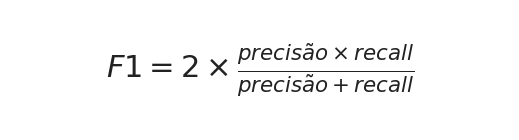

In [24]:
import matplotlib.pyplot as plt

# 1. Diminuímos o tamanho da figura (de 6x2.5 para 5x1.2) para cortar o excesso de branco
fig, ax = plt.subplots(figsize=(5, 1.2))

fórmula_f1 = r'$F1 = 2 \times \frac{precis\tilde{a}o \times recall}{precis\tilde{a}o + recall}$'

# 2. Centralizamos o texto usando coordenadas fixas
ax.text(0.5, 0.5, fórmula_f1, fontsize=22, ha='center', va='center', color='#222222')

# 3. Travamos os limites bem justos para eliminar as margens invisíveis
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# O pad=0 remove qualquer margem restante nas bordas externas
plt.tight_layout(pad=0)
plt.show()


Curva ROC

In [25]:
from sklearn.metrics import RocCurveDisplay

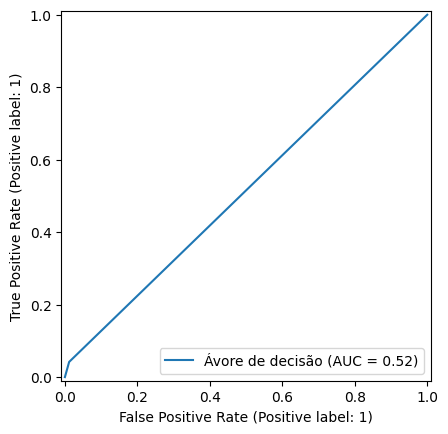

In [26]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name='Ávore de decisão');

In [27]:
from sklearn.metrics import roc_auc_score

In [28]:
print(f'AUC: {roc_auc_score(y_val, y_previsto)}')

AUC: 0.5150892032139558


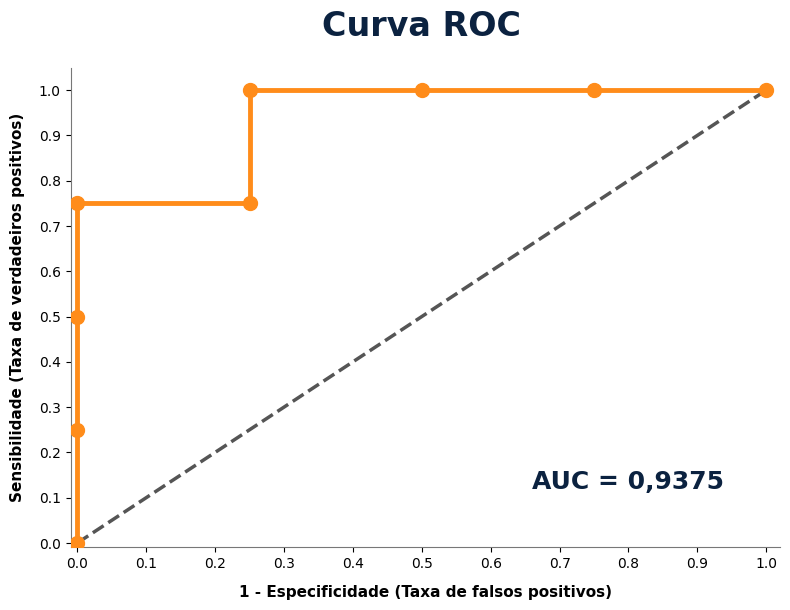

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuração da figura com bordas limpas
fig, ax = plt.subplots(figsize=(8, 6.2))

# 2. Definição dos pontos da curva (Extraídos do gráfico)
x_pontos = [0, 0, 0, 0, 0.25, 0.25, 0.5, 0.75, 1]
y_pontos = [0, 0.25, 0.5, 0.75, 0.75, 1, 1, 1, 1]

# 3. Plotagem das linhas e elementos visuais
# Linha pontilhada diagonal de referência (cinza escuro)
ax.plot([0, 1], [0, 1], color='#555555', linestyle='--', linewidth=2.5)

# Curva ROC principal (linha laranja contínua)
ax.plot(x_pontos, y_pontos, color='#ff8c1a', linewidth=3.5, zorder=2)

# Marcadores redondos nos vértices dos pontos (laranja)
ax.scatter(x_pontos, y_pontos, color='#ff8c1a', s=100, zorder=3)

# 4. Título e Textos Informativos (Centralizados)
# Mudamos o X para 0.5 e o alinhamento horizontal (ha) para 'center'
ax.text(0.5, 1.12, 'Curva ROC', fontsize=24, fontweight='bold', color='#0b2240', ha='center')

# O texto da AUC foi levemente reajustado para ficar centralizado no canto inferior direito
ax.text(0.80, 0.12, 'AUC = 0,9375', fontsize=18, fontweight='bold', color='#0b2240', ha='center')

# 5. Configuração detalhada dos Eixos
ax.set_xlabel('1 - Especificidade (Taxa de falsos positivos)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Sensibilidade (Taxa de verdadeiros positivos)', fontsize=11, fontweight='bold', labelpad=10)

# Valores fixos dos eixos de 0 a 1 (passo de 0,1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))

# Ajuste fino dos limites para colar o gráfico nas bordas e sumir com espaços vazios
ax.set_xlim(-0.01, 1.02)
ax.set_ylim(-0.01, 1.05)

# Remove as bordas superior e direita do gráfico para o estilo limpo do slide
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#777777')
ax.spines['bottom'].set_color('#777777')

plt.tight_layout()
plt.show()


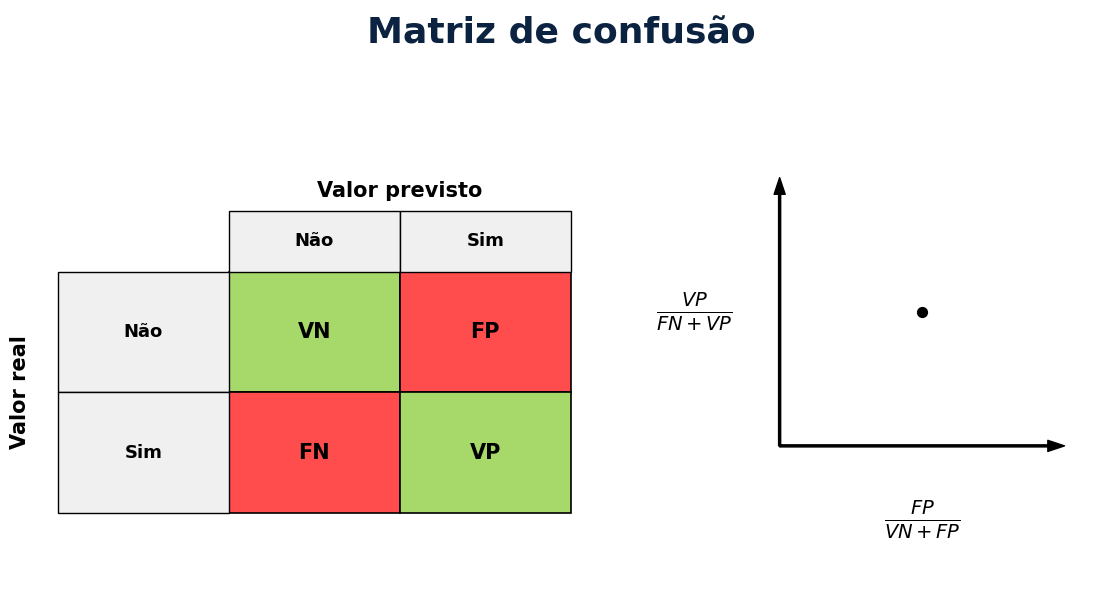

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuração da figura (tamanho horizontal mantido para o equilíbrio dos lados)
fig, ax = plt.subplots(figsize=(11, 6))

# Cores oficiais do slide
cor_acerto = '#a6d96a'     # Verde claro (VN / VP)
cor_erro = '#ff4d4d'       # Vermelho vivo (FP / FN)
cor_titulo = '#0b2240'     # Azul escuro

# Título Principal (Centralizado)
ax.text(5.5, 9.0, 'Matriz de confusão', fontsize=26, fontweight='bold', color=cor_titulo, ha='center')

# =========================================================================
# LADO ESQUERDO: MATRIZ DE CONFUSÃO (PROPORÇÃO AUMENTADA)
# =========================================================================

# Tamanho dos blocos aumentado de 1.3 para 1.8
tamanho_bloco = 1.8
tamanho_rotulo_h = 0.9

# Posições de referência para o novo alinhamento
x_col1 = 2.0
x_col2 = x_col1 + tamanho_bloco  # 3.8
y_linha2 = 2.0
y_linha1 = y_linha2 + tamanho_bloco  # 4.8

# Quadrantes Principais
# VN (Verde)
ax.add_patch(patches.Rectangle((x_col1, y_linha1), tamanho_bloco, tamanho_bloco, edgecolor='black', facecolor=cor_acerto, lw=1.2))
ax.text(x_col1 + tamanho_bloco/2, y_linha1 + tamanho_bloco/2, 'VN', fontsize=15, fontweight='bold', ha='center', va='center')

# FP (Vermelho)
ax.add_patch(patches.Rectangle((x_col2, y_linha1), tamanho_bloco, tamanho_bloco, edgecolor='black', facecolor=cor_erro, lw=1.2))
ax.text(x_col2 + tamanho_bloco/2, y_linha1 + tamanho_bloco/2, 'FP', fontsize=15, fontweight='bold', ha='center', va='center')

# FN (Vermelho)
ax.add_patch(patches.Rectangle((x_col1, y_linha2), tamanho_bloco, tamanho_bloco, edgecolor='black', facecolor=cor_erro, lw=1.2))
ax.text(x_col1 + tamanho_bloco/2, y_linha2 + tamanho_bloco/2, 'FN', fontsize=15, fontweight='bold', ha='center', va='center')

# VP (Verde)
ax.add_patch(patches.Rectangle((x_col2, y_linha2), tamanho_bloco, tamanho_bloco, edgecolor='black', facecolor=cor_acerto, lw=1.2))
ax.text(x_col2 + tamanho_bloco/2, y_linha2 + tamanho_bloco/2, 'VP', fontsize=15, fontweight='bold', ha='center', va='center')

# Rótulos de "Não" e "Sim"
# Colunas (Valor previsto)
y_previsto_topo = y_linha1 + tamanho_bloco
ax.add_patch(patches.Rectangle((x_col1, y_previsto_topo), tamanho_bloco, tamanho_rotulo_h, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(x_col1 + tamanho_bloco/2, y_previsto_topo + tamanho_rotulo_h/2, 'Não', fontsize=13, fontweight='bold', ha='center', va='center')

ax.add_patch(patches.Rectangle((x_col2, y_previsto_topo), tamanho_bloco, tamanho_rotulo_h, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(x_col2 + tamanho_bloco/2, y_previsto_topo + tamanho_rotulo_h/2, 'Sim', fontsize=13, fontweight='bold', ha='center', va='center')

# Linhas (Valor real)
x_real_esquerda = x_col1 - tamanho_bloco
ax.add_patch(patches.Rectangle((x_real_esquerda, y_linha1), tamanho_bloco, tamanho_bloco, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(x_real_esquerda + tamanho_bloco/2, y_linha1 + tamanho_bloco/2, 'Não', fontsize=13, fontweight='bold', ha='center', va='center')

ax.add_patch(patches.Rectangle((x_real_esquerda, y_linha2), tamanho_bloco, tamanho_bloco, edgecolor='black', facecolor='#f0f0f0', lw=1))
ax.text(x_real_esquerda + tamanho_bloco/2, y_linha2 + tamanho_bloco/2, 'Sim', fontsize=13, fontweight='bold', ha='center', va='center')

# Textos Indicadores dos Eixos (Centralizados com base no novo tamanho)
ax.text(x_col1 + tamanho_bloco, y_previsto_topo + tamanho_rotulo_h + 0.3, 'Valor previsto', fontsize=15, fontweight='bold', ha='center', va='center')
ax.text(x_real_esquerda - 0.4, y_linha2 + tamanho_bloco, 'Valor real', fontsize=15, fontweight='bold', rotation=90, ha='center', va='center')

# =========================================================================
# LADO DIREITO: GRÁFICO CARTESIANO COM AS FÓRMULAS
# =========================================================================

# Ajustamos o início do gráfico cartesiano um pouco mais para a direita (X=7.8) para dar espaço à matriz maior
ax.annotate('', xy=(7.8, 7.0), xytext=(7.8, 3.0), arrowprops=dict(facecolor='black', width=1.5, headwidth=8, shrink=0))
ax.annotate('', xy=(10.8, 3.0), xytext=(7.8, 3.0), arrowprops=dict(facecolor='black', width=1.5, headwidth=8, shrink=0))

# Ponto cartesiano isolado
ax.scatter([9.3], [5.0], color='black', s=50, zorder=5)

# Fórmula Matemática do Eixo Y
ax.text(6.9, 5.0, r'$\frac{VP}{FN + VP}$', fontsize=20, ha='center', va='center')

# Fórmula Matemática do Eixo X
ax.text(9.3, 1.9, r'$\frac{FP}{VN + FP}$', fontsize=20, ha='center', va='center')

# =========================================================================
# CONFIGURAÇÕES FINAIS DE BORDA E EXIBIÇÃO
# =========================================================================
ax.set_xlim(0, 11)
ax.set_ylim(1, 9.5)
ax.axis('off')

plt.tight_layout()
plt.show()


In [31]:
# Curva de precisão x Recall



In [32]:
from sklearn.metrics import PrecisionRecallDisplay

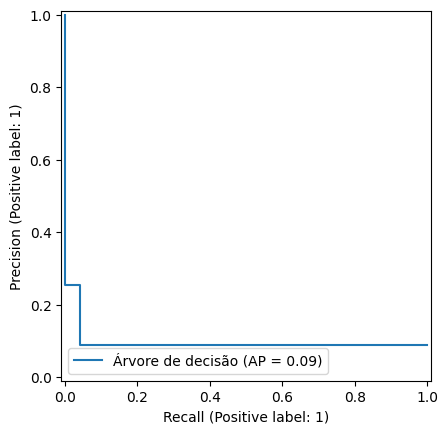

In [33]:
PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name='Árvore de decisão');

In [34]:
from sklearn.metrics import average_precision_score

In [35]:
print(f'AP: {average_precision_score(y_val, y_previsto)}')

AP: 0.0942859796714147


In [36]:
from sklearn.metrics import classification_report


In [37]:
print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.25      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.58      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481



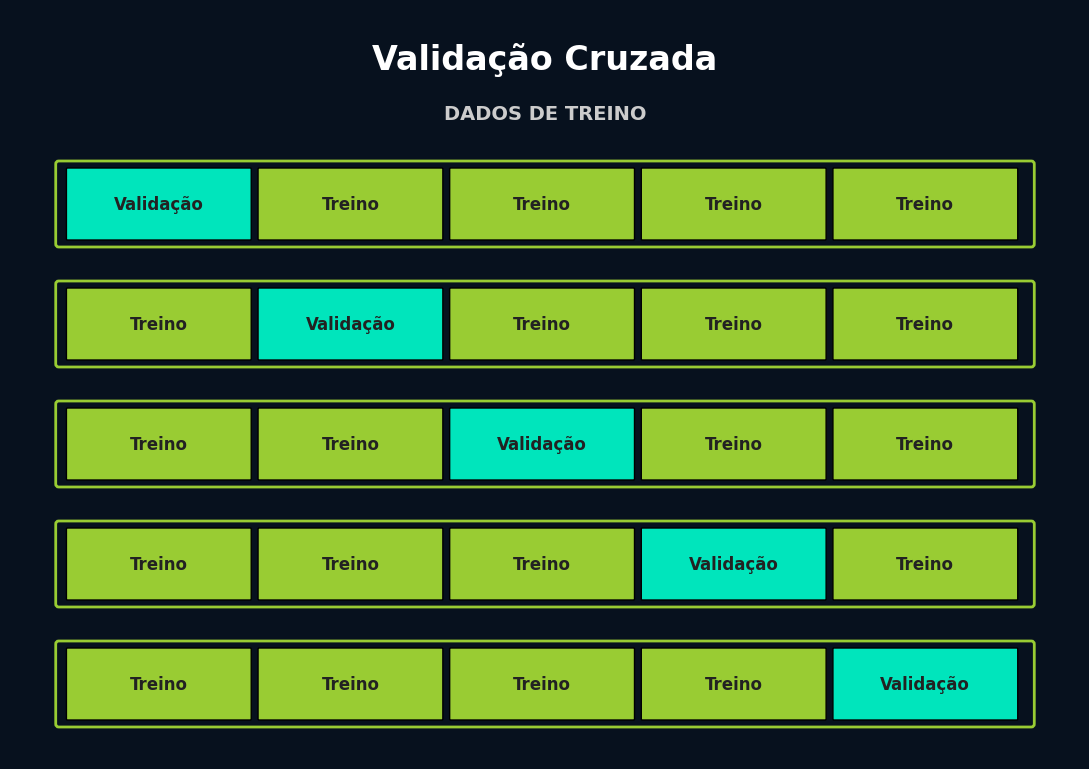

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Configuração da figura
fig, ax = plt.subplots(figsize=(11, 7.8))

cor_validacao = '#00e5bc'  
cor_treino = '#99cc33'     
cor_borda = '#99cc33'      

ax.text(5.5, 6.9, 'Validação Cruzada', fontsize=24, fontweight='bold', color='white', ha='center')
ax.text(5.5, 6.4, 'DADOS DE TREINO', fontsize=14, fontweight='bold', color='#cccccc', ha='center')

largura_bloco = 1.88
altura_bloco = 0.7
posicoes_x_base = [0.57, 2.54, 4.51, 6.48, 8.45]
deslocamento_manual = 0.02

posicoes_x = [pos + deslocamento_manual for pos in posicoes_x_base]

# 2. Loop para desenhar as 5 iterações completas
for iteracao in range(5):
    y_linha = 5.2 - (iteracao * 1.2)
    
    moldura = patches.FancyBboxPatch((0.5, y_linha - 0.05), 10.0, altura_bloco + 0.1, boxstyle="round,pad=0.03",
                                      edgecolor=cor_borda, facecolor='none', lw=2.0)
    ax.add_patch(moldura)
    
    # loop corrigido com pos_x em todas as linhas internas
    for idx, pos_x in enumerate(posicoes_x):
        if idx == iteracao:
            cor_atual = cor_validacao
            texto_atual = 'Validação'
        else:
            cor_atual = cor_treino
            texto_atual = 'Treino'
            
        ax.add_patch(patches.FancyBboxPatch((pos_x, y_linha), largura_bloco, altura_bloco, boxstyle="round,pad=0.01", 
                                          edgecolor='black', facecolor=cor_atual, lw=1))
        ax.text(pos_x + largura_bloco/2, y_linha + altura_bloco/2, texto_atual, fontsize=12, fontweight='bold', 
                ha='center', va='center', color='#222222')

fig.patch.set_facecolor('#07111e')
ax.set_facecolor('#07111e')
ax.set_xlim(0, 11)
ax.set_ylim(0, 7.5)
ax.axis('off')

plt.tight_layout()
plt.show()


In [39]:
from sklearn.model_selection import cross_validate, KFold


In [ ]:
modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x, y, cv = kf)
cv_resultados

{'fit_time': array([0.12445521, 0.12230611, 0.12102532, 0.12185621, 0.12235618]),
 'score_time': array([0.00229836, 0.00222707, 0.00218534, 0.00225735, 0.00228333]),
 'test_score': array([0.9127926 , 0.90766551, 0.90777439, 0.91332753, 0.89917247])}

In [42]:
cv_resultados['test_score']

array([0.9127926 , 0.90766551, 0.90777439, 0.91332753, 0.89917247])

In [46]:
media= cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
print(f'intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

intervalo de confiança: [0.8979746859040525, 0.9183183109340736]


In [48]:
def intervalo_conf(resultados):
    media = resultados['test_score'].mean()
    desvio_padrao = resultados['test_score'].std()
    print(f'intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

In [49]:
modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x, y, cv = kf, scoring = 'recall')
cv_resultados 

{'fit_time': array([0.13341475, 0.12201405, 0.12271976, 0.12153339, 0.12820005]),
 'score_time': array([0.00398183, 0.0037961 , 0.00389338, 0.00377965, 0.00382304]),
 'test_score': array([0.02642008, 0.01856436, 0.01845018, 0.01697128, 0.02543353])}

In [50]:
intervalo_conf(cv_resultados)

intervalo de confiança: [0.0132909824991133, 0.02904478773394878]


Estratificando os dados

In [51]:
dados['inadimplente'].value_counts(normalize=True)

inadimplente
0    0.912707
1    0.087293
Name: proportion, dtype: float64

In [52]:
from sklearn.model_selection import StratifiedKFold

In [53]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x, y, cv=skf, scoring='recall')

In [54]:
intervalo_conf(cv_resultados)

intervalo de confiança: [0.02093997806316359, 0.03393594075402565]


In [56]:
from imblearn.over_sampling import SMOTE

In [57]:
oversample = SMOTE()
x_balanceado, y_balanceado = oversample.fit_resample(x, y)

In [58]:
y_balanceado.value_counts(normalize = True)

inadimplente
0    0.5
1    0.5
Name: proportion, dtype: float64

In [59]:
modelo = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x_balanceado, y_balanceado, cv=skf, scoring = 'recall')

In [60]:
intervalo_conf(cv_resultados)

intervalo de confiança: [0.6995555050109783, 0.7339244675949532]


In [61]:
from imblearn.pipeline import Pipeline as imbpipeline


In [62]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', modelo)])

In [63]:
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring = 'recall')

In [64]:
intervalo_conf(cv_resultados)

intervalo de confiança: [0.22039003478234667, 0.30144457968024835]


In [65]:
from imblearn.under_sampling import NearMiss

In [66]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])

In [67]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring = 'recall')

In [68]:
intervalo_conf(cv_resultados)

intervalo de confiança: [0.6203605633785977, 0.7001496467390546]


Testando o modelo 

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



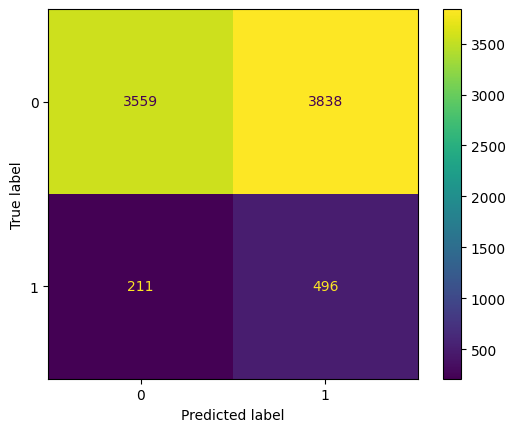

In [74]:
undersample = NearMiss(version=3)
x_balanceado, y_balanceado = undersample.fit_resample(x, y)

modelo = DecisionTreeClassifier(max_depth = 10)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(x_teste)

print(classification_report(y_teste, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto);

